# 01 — Построение временного ряда загрузки санатория

## Цель ноутбука

Этот ноутбук формирует базовый временной ряд для всего forecasting pipeline. На входе у нас транзакционные данные бронирований, где одна бронь может быть разбита на несколько строк по тарифам/периодам. На выходе нужен ежедневный ряд активных бронирований.

## Что делаем

1. Загружаем `silver.csv`.
2. Оставляем только `is_valid == 1`: остальные строки не используем в прогнозе, потому что это анонимные записи без надежного `guest_id`.
3. Используем `grp_norm` как идентификатор бронирования.
4. Разворачиваем каждое бронирование в набор ежедневных дат проживания.
5. Считаем `y` — количество активных бронирований в день.
6. Добавляем календарные признаки и сезон.
7. Оцениваем годовой номерной фонд как p99 дневных активных бронирований и считаем `load_rate = y / capacity_est`.
8. До построения моделей проводим EDA временного ряда: тренд, сезонность, календарные эффекты, автокорреляция и остатки.
9. Строим дополнительный ряд по сегментам для рекомендательного модуля.

## Главный результат

- `artifacts_forecasting/df_daily.parquet` — общий ежедневный ряд.
- `artifacts_forecasting/df_daily_segment.parquet` — ежедневный ряд по сегментам.
- `artifacts_forecasting/capacity_by_year.csv` — оценка номерного фонда по годам.
- `artifacts_forecasting/eda_*.png` — графики предварительного анализа временного ряда для отчета и защиты.

## 1. Импорты и настройки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import holidays
import warnings
warnings.filterwarnings('ignore')

# ── Пути к данным ──────────────────────────────────────────────────────────────
ROOT = Path('..').resolve()          # корень ml/
DATA_DIR   = ROOT / 'data'
CLUSTER_DIR = ROOT / 'clustering' / 'artifacts_v4'
OUT_DIR    = Path('artifacts_forecasting')
OUT_DIR.mkdir(exist_ok=True)

# ── Параметры фильтрации ───────────────────────────────────────────────────────
DATA_START = '2022-01-01'   # исключаем COVID и нестабильный 2019–2021
# Конец истории нельзя задавать будущей датой: после даты выгрузки данные правоцензурированы.
# HISTORY_END вычисляем после загрузки как max(created_dt), т.е. дата среза выгрузки.
HISTORY_END = None


print('Пути настроены:')
print(f'  Данные:     {DATA_DIR}')
print(f'  Кластеры:   {CLUSTER_DIR}')
print(f'  Выход:      {OUT_DIR.resolve()}')

Пути настроены:
  Данные:     C:\workspace\my_project\diplom\booking\ml\data
  Кластеры:   C:\workspace\my_project\diplom\booking\ml\clustering\artifacts_v4
  Выход:      C:\workspace\my_project\diplom\booking\ml\forecasting\artifacts_forecasting


## 2. Загрузка сырых данных

Загружаем `silver.csv` — основной файл бронирований.  
Нам нужны только ключевые колонки, чтобы не держать в памяти всё.

In [2]:
COLS = [
    'created_dt',
    'grp_norm',
    'guest_id',
    'check_in_dt',
    'check_out_dt',
    'is_valid',
    'tariff',
]

df_raw = pd.read_csv(
    DATA_DIR / 'silver.csv',
    usecols=COLS,
    parse_dates=['created_dt', 'check_in_dt', 'check_out_dt'],
    low_memory=False
)

HISTORY_END = df_raw['created_dt'].max().normalize()

print(f'Загружено строк: {len(df_raw):,}')
print(f'Колонки: {list(df_raw.columns)}')
print(f'Дата среза выгрузки (max created_dt): {HISTORY_END.date()}')
df_raw.head()

Загружено строк: 565,816
Колонки: ['created_dt', 'check_in_dt', 'check_out_dt', 'is_valid', 'tariff', 'grp_norm', 'guest_id']
Дата среза выгрузки (max created_dt): 2025-10-30


,created_dt,check_in_dt,check_out_dt,is_valid,tariff,grp_norm,guest_id
0,2020-12-01,2021-01-30 14:00:00,2021-02-01 12:00:00,0,Все Включено 2021,923160,NaN
1,2020-12-01,2020-12-15 14:00:00,2020-12-22 12:00:00,1,Открытый Юг/Доступный Юг от 7 суток 2020г.,923196,1370402.0
2,2020-12-01,2021-01-30 14:00:00,2021-02-04 12:00:00,0,Все Включено 2021,923143,NaN
3,2020-12-01,2021-02-19 14:00:00,2021-02-23 12:00:00,1,Все Включено 2021,923137,1381805.0
4,2020-12-01,2021-01-11 14:00:00,2021-01-17 12:00:00,0,Все Включено 2021,923133,NaN


## 3. Фильтрация данных

Здесь фиксируем правила отбора данных перед построением временного ряда.

Ключевое решение: фильтр `is_valid == 1` оставляем. В этой задаче это корректно, потому что остальные записи не имеют надежного `guest_id` и не подходят для последующей связи с сегментами клиентов. Для самого временного ряда мы считаем активные бронирования через `grp_norm`, который используем как идентификатор бронирования.

In [3]:
print('=== Фильтрация данных ===')
print(f'Исходных строк: {len(df_raw):,}')

# Фильтр 1: только валидные бронирования
df = df_raw[df_raw['is_valid'] == 1].copy()
print(f'После is_valid==1: {len(df):,}')

# Фильтр 2: оба поля дат должны быть заполнены
df = df.dropna(subset=['check_in_dt', 'check_out_dt'])
print(f'После dropna дат: {len(df):,}')

# Фильтр 3: check_out > check_in (логическая проверка)
df = df[df['check_out_dt'] > df['check_in_dt']]
print(f'После check_out > check_in: {len(df):,}')

# Фильтр 4: только данные с 2022-01-01 до даты среза выгрузки.
# Заезды после HISTORY_END не являются фактической историей, а только будущими бронями на дату выгрузки.
df = df[df['check_in_dt'] >= DATA_START]
df = df[df['check_in_dt'] <= HISTORY_END]
df = df[df['check_out_dt'] >= DATA_START]
print(f'После фильтра дат ({DATA_START} — {HISTORY_END.date()}): {len(df):,}')

# Фильтр 5: исключаем служебные тарифы (сотрудники, технические записи)
service_mask = df['tariff'].str.contains(
    r'Служебный|СОТРУДНИКИ|Сотрудник|НЕ СЕЛИТЬ', na=False, regex=True
)
df = df[~service_mask]
print(f'После исключения служебных тарифов: {len(df):,}')

# Фильтр 6: исключаем ФСС / корпоративные путёвки (B2B, не рыночный спрос)
corp_mask = df['tariff'].str.contains(
    r'ФСС|Согаз|корпор|КОРПОР', na=False, regex=True
)
df = df[~corp_mask]
print(f'После исключения ФСС/корпоративных: {len(df):,}')

print(f'\nДиапазон дат заезда: {df["check_in_dt"].min().date()} — {df["check_in_dt"].max().date()}')

=== Фильтрация данных ===
Исходных строк: 565,816
После is_valid==1: 521,143
После dropna дат: 521,143
После check_out > check_in: 521,143
После фильтра дат (2022-01-01 — 2025-10-30): 374,958
После исключения служебных тарифов: 347,872
После исключения ФСС/корпоративных: 324,109

Диапазон дат заезда: 2022-01-01 — 2025-10-29


## 4. Развёртка бронирований в ежедневные записи

Одна строка в исходных данных не равна одному дню загрузки. Поэтому каждое бронирование разворачиваем в календарные даты от `check_in_dt` до `check_out_dt`.

Важно: для одного `grp_norm` берем минимальный `check_in_dt` и максимальный `check_out_dt`. Это защищает от ситуации, когда одно бронирование разбито на несколько тарифных строк.

In [4]:
# Для каждого grp_norm берём min(check_in) и max(check_out) — полный период пребывания,
# а не только один тарифный sub-период
df_bookings = (
    df.groupby('grp_norm', as_index=False)
    .agg(
        check_in_dt  = ('check_in_dt',  'min'),
        check_out_dt = ('check_out_dt', 'max'),
    )
)

# Нормализуем время до полуночи, чтобы reindex корректно совпадал
df_bookings['check_in_dt']  = df_bookings['check_in_dt'].dt.normalize()
df_bookings['check_out_dt'] = df_bookings['check_out_dt'].dt.normalize()

print(f'Уникальных бронирований: {len(df_bookings):,}')

df_bookings['date'] = df_bookings.apply(
    lambda row: pd.date_range(
        start=row['check_in_dt'],
        end=row['check_out_dt'],
        inclusive='left'
    ),
    axis=1
)

df_exploded = df_bookings.explode('date')[['grp_norm', 'date']].reset_index(drop=True)

# Отсекаем дни за пределами наблюдаемой истории [DATA_START, HISTORY_END]
df_exploded = df_exploded[
    (df_exploded['date'] >= DATA_START) &
    (df_exploded['date'] <= HISTORY_END)
]

print(f'Строк после развёртки: {len(df_exploded):,}')
print(f'Диапазон дат: {df_exploded["date"].min().date()} — {df_exploded["date"].max().date()}')
df_exploded.head(6)

Уникальных бронирований: 83,973
Строк после развёртки: 613,354
Диапазон дат: 2022-01-01 — 2025-10-30


,grp_norm,date
0,900986,2023-10-09
1,900986,2023-10-10
2,900986,2023-10-11
3,900986,2023-10-12
4,900986,2023-10-13
5,900986,2023-10-14


## 5. Агрегация: ежедневная загрузка

Теперь группируем по дате и считаем количество уникальных бронирований (`grp_norm`) на каждый день.  
Это и есть наша метрика загрузки.

После агрегации создаём **непрерывный календарный индекс** — добавляем все дни в диапазоне, даже если в какой-то день не было гостей (тогда y=0). Это обязательно для временных рядов.

In [5]:
df_occ = (
    df_exploded
    .groupby('date')['grp_norm']
    .nunique()
    .reset_index()
    .rename(columns={'grp_norm': 'y', 'date': 'ds'})
)

df_occ['ds'] = pd.to_datetime(df_occ['ds'])

# Явно ограничиваем ряд: от DATA_START до даты среза выгрузки
full_index = pd.date_range(start=DATA_START, end=HISTORY_END, freq='D')
df_occ = (
    df_occ
    .set_index('ds')
    .reindex(full_index, fill_value=0)
    .rename_axis('ds')
    .reset_index()
)

print(f'Временной ряд: {df_occ["ds"].min().date()} — {df_occ["ds"].max().date()}')
print(f'Количество дней в ряду: {len(df_occ):,}')
print(f'Средняя ежедневная загрузка: {df_occ["y"].mean():.1f} бронирований/день')
print(f'Максимальная загрузка: {df_occ["y"].max()} бронирований/день')
print(f'Дней с нулевой загрузкой: {(df_occ["y"] == 0).sum()}')
df_occ.head()

Временной ряд: 2022-01-01 — 2025-10-30
Количество дней в ряду: 1,399
Средняя ежедневная загрузка: 438.4 бронирований/день
Максимальная загрузка: 992 бронирований/день
Дней с нулевой загрузкой: 0


,ds,y
0,2022-01-01,126
1,2022-01-02,355
2,2022-01-03,639
3,2022-01-04,672
4,2022-01-05,613


## 6. Добавляем вспомогательные признаки к ряду

Добавляем колонки, которые пригодятся при анализе и построении модели:
- **`season`** — сезон (winter/spring/summer/autumn)
- **`weekday`** — день недели (0=понедельник, 6=воскресенье)
- **`is_weekend`** — флаг выходного дня
- **`month`**, **`year`** — для группировок

In [6]:
# Функция для определения сезона по месяцу
def month_to_season(month: int) -> str:
    """Возвращает сезон по номеру месяца."""
    if month in (12, 1, 2):
        return 'winter'
    elif month in (3, 4, 5):
        return 'spring'
    elif month in (6, 7, 8):
        return 'summer'
    else:
        return 'autumn'

df_occ['month']       = df_occ['ds'].dt.month
df_occ['year']        = df_occ['ds'].dt.year
df_occ['weekday']     = df_occ['ds'].dt.dayofweek        # 0=Пн, 6=Вс
df_occ['day_of_week'] = df_occ['weekday']                # алиас для совместимости
df_occ['week']        = df_occ['ds'].dt.isocalendar().week.astype(int)
df_occ['is_weekend']  = (df_occ['weekday'] >= 5).astype(int)
df_occ['season']      = df_occ['month'].map(month_to_season)

# ── Календарь праздников ───────────────────────────────────────────────────────
ru_holidays = holidays.Russia(years=range(2019, 2030))
df_occ['is_holiday'] = df_occ['ds'].dt.date.isin(ru_holidays.keys()).astype(int)
df_occ['is_day_off'] = ((df_occ['is_holiday'] == 1) | (df_occ['is_weekend'] == 1)).astype(int)

print('Распределение загрузки по сезонам:')
print(df_occ.groupby('season')['y'].agg(['mean', 'min', 'max']).round(1))

print(f'\nПраздничных дней в ряду:  {df_occ["is_holiday"].sum()}')
print(f'Выходных + праздников:    {df_occ["is_day_off"].sum()}')
print('\nПервые 5 строк итогового ряда:')
df_occ.head()

Распределение загрузки по сезонам:
         mean  min  max
season                 
autumn  479.3  143  992
spring  353.0   81  683
summer  685.4  348  985
winter  217.1   64  817

Праздничных дней в ряду:  71
Выходных + праздников:    456

Первые 5 строк итогового ряда:


,ds,y,month,year,weekday,day_of_week,week,is_weekend,season,is_holiday,is_day_off
0,2022-01-01,126,1,2022,5,5,52,1,winter,1,1
1,2022-01-02,355,1,2022,6,6,52,1,winter,1,1
2,2022-01-03,639,1,2022,0,0,1,0,winter,1,1
3,2022-01-04,672,1,2022,1,1,1,0,winter,1,1
4,2022-01-05,613,1,2022,2,2,1,0,winter,1,1


## 7. Оценка номерного фонда по годам и load_rate

В 2024 году изменился номерной фонд, поэтому абсолютные активные бронирования нельзя напрямую сравнивать между всеми годами. Чтобы модель не интерпретировала изменение фонда как изменение спроса, добавляем нормированную цель.

Методика:

- `capacity_est` = 99-й перцентиль дневных активных бронирований внутри года;
- `load_rate` = `y / capacity_est`;
- `y` сохраняем как бизнес-метрику в активных бронированиях;
- `load_rate` используем дальше как целевую переменную для моделей.

Почему p99, а не максимум: максимум может быть единичным выбросом, а p99 устойчивее и при этом близок к фактическому верхнему уровню фонда.

In [7]:
CAPACITY_QUANTILE = 0.99

capacity_by_year = (
    df_occ.groupby('year')['y']
    .quantile(CAPACITY_QUANTILE)
    .round()
    .astype(int)
    .to_dict()
)

df_occ['capacity_est'] = df_occ['year'].map(capacity_by_year).astype(float)
df_occ['load_rate'] = (df_occ['y'] / df_occ['capacity_est']).clip(lower=0, upper=1.2)

capacity_check = (
    df_occ.groupby('year')
    .agg(
        max_y=('y', 'max'),
        p99_y=('y', lambda s: s.quantile(CAPACITY_QUANTILE)),
        p98_y=('y', lambda s: s.quantile(0.98)),
        mean_y=('y', 'mean'),
        capacity_est=('capacity_est', 'first'),
        days=('y', 'size'),
    )
    .round(1)
    .reset_index()
)

print('Estimated yearly capacity from p99 active bookings:')
display(capacity_check)


Estimated yearly capacity from p99 active bookings:


,year,max_y,p99_y,p98_y,mean_y,capacity_est,days
0,2022,980,961.2,934.6,376.4,961.0,365
1,2023,992,982.4,966.7,522.0,982.0,365
2,2024,861,824.0,812.8,419.1,824.0,366
3,2025,813,779.0,777.0,435.8,779.0,303


## 8. EDA временного ряда перед моделированием

Перед Prophet и XGBoost фиксируем базовые свойства ряда. Эти графики отвечают на вопросы, которые обычно задают до выбора модели:

- есть ли общий тренд и менялась ли емкость санатория;
- насколько сильна годовая, месячная и недельная сезонность;
- отличаются ли выходные, праздники и обычные дни;
- есть ли автокорреляция и выраженные лаги;
- где остаются выбросы после выделения тренда и сезонности.

Для моделирования дальше используем `load_rate`, если доступен `capacity_est`: это снижает искажение от изменения номерного фонда между годами.

In [8]:
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use('seaborn-v0_8-whitegrid')
MONTH_LABELS = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
WEEKDAY_LABELS = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
TARGET_FOR_EDA = 'load_rate' if 'load_rate' in df_occ.columns else 'y'
TARGET_LABEL = 'Load rate' if TARGET_FOR_EDA == 'load_rate' else 'Активные бронирования'

def save_current_fig(filename: str) -> None:
    path = OUT_DIR / filename
    plt.savefig(path, dpi=160, bbox_inches='tight')
    print(f'Сохранено: {path}')


Сохранено: artifacts_forecasting\eda_history_trend_capacity.png


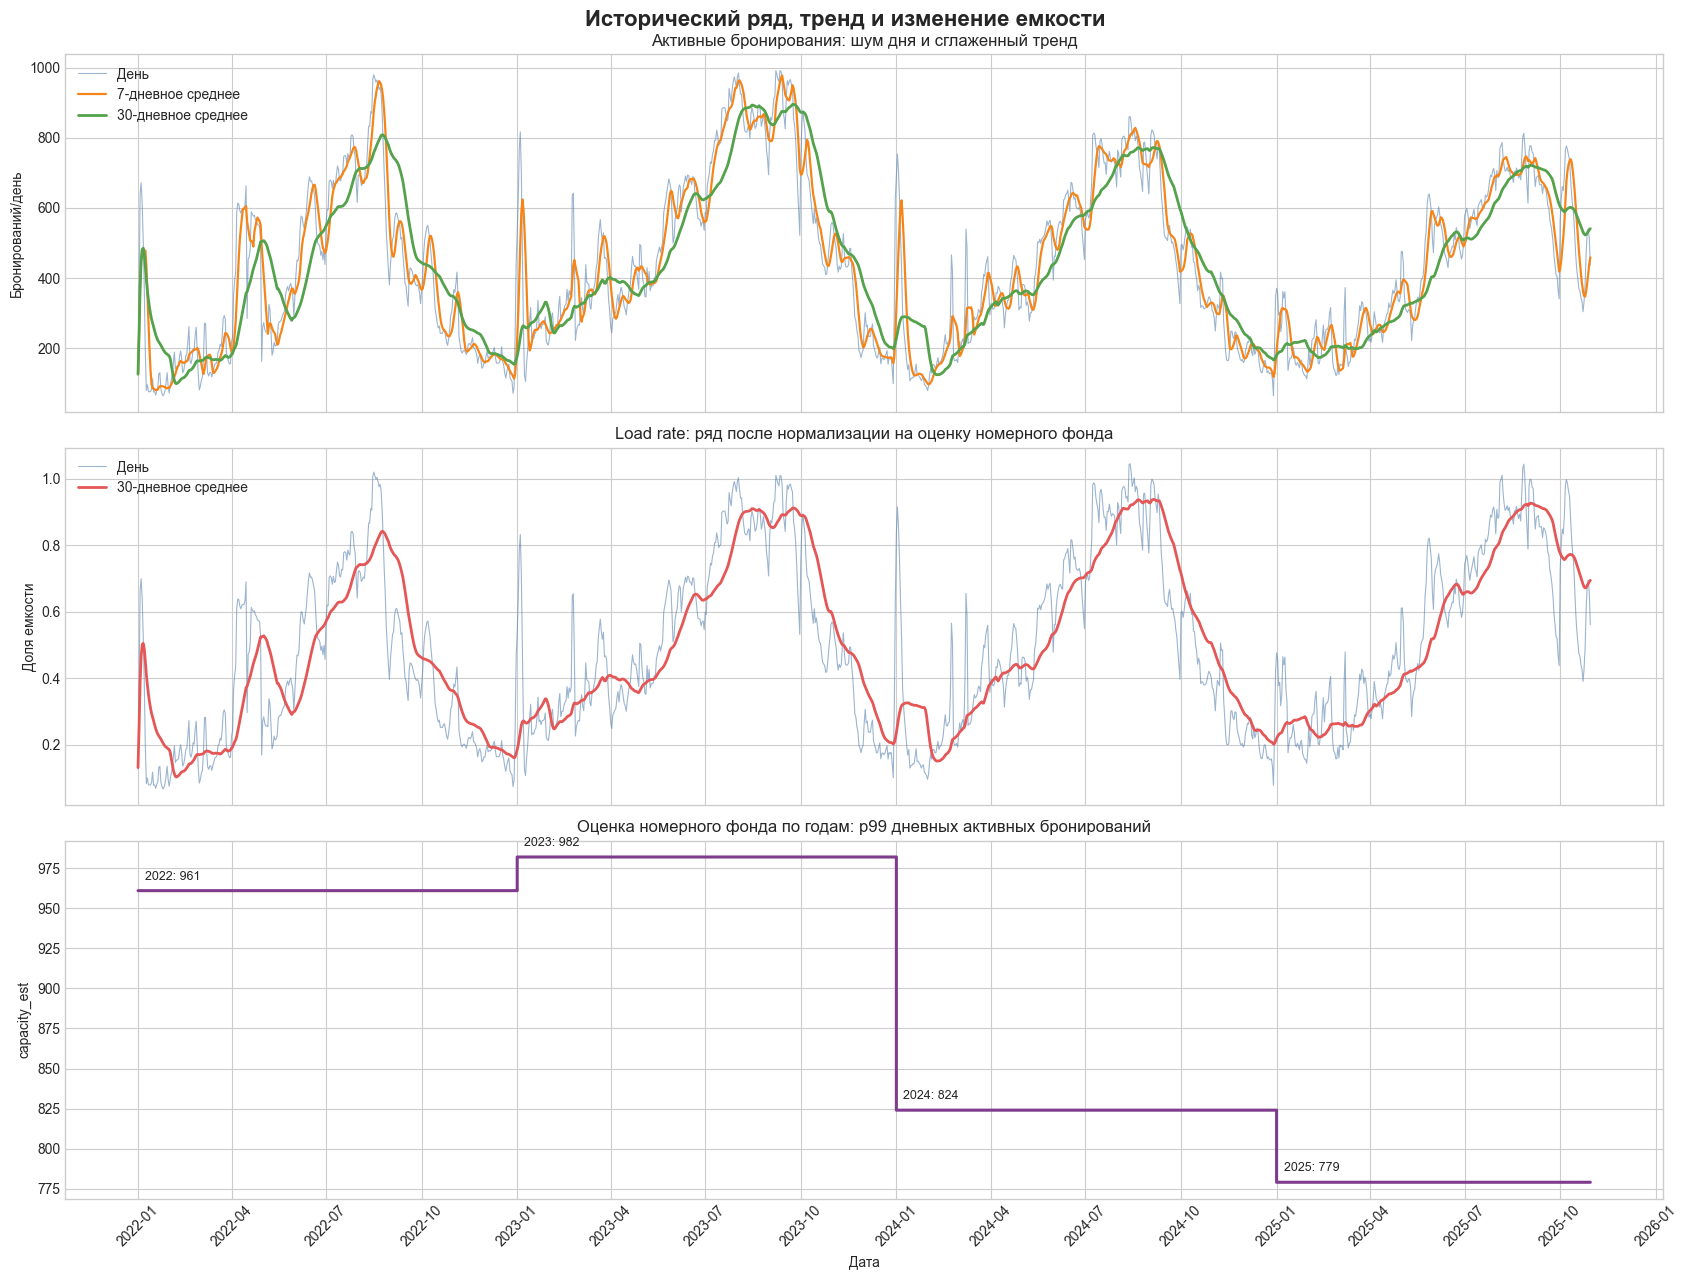

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(17, 13), sharex=True)
fig.suptitle('Исторический ряд, тренд и изменение емкости', fontsize=16, fontweight='bold')

axes[0].plot(df_occ['ds'], df_occ['y'], color='#4C78A8', linewidth=0.8, alpha=0.55, label='День')
axes[0].plot(df_occ['ds'], df_occ['y'].rolling(7, min_periods=1).mean(), color='#F58518', linewidth=1.6, label='7-дневное среднее')
axes[0].plot(df_occ['ds'], df_occ['y'].rolling(30, min_periods=1).mean(), color='#54A24B', linewidth=2.0, label='30-дневное среднее')
axes[0].set_title('Активные бронирования: шум дня и сглаженный тренд')
axes[0].set_ylabel('Бронирований/день')
axes[0].legend(loc='upper left')

axes[1].plot(df_occ['ds'], df_occ['load_rate'], color='#4C78A8', linewidth=0.8, alpha=0.55, label='День')
axes[1].plot(df_occ['ds'], df_occ['load_rate'].rolling(30, min_periods=1).mean(), color='#E45756', linewidth=2.0, label='30-дневное среднее')
axes[1].set_title('Load rate: ряд после нормализации на оценку номерного фонда')
axes[1].set_ylabel('Доля емкости')
axes[1].legend(loc='upper left')

capacity_steps = df_occ.drop_duplicates('year')[['ds', 'year', 'capacity_est']]
axes[2].step(df_occ['ds'], df_occ['capacity_est'], where='post', color='#7F3C8D', linewidth=2.2)
for _, row in capacity_steps.iterrows():
    axes[2].annotate(f'{int(row["year"])}: {int(row["capacity_est"])}', xy=(row['ds'], row['capacity_est']), xytext=(5, 8), textcoords='offset points', fontsize=9)
axes[2].set_title('Оценка номерного фонда по годам: p99 дневных активных бронирований')
axes[2].set_ylabel('capacity_est')
axes[2].set_xlabel('Дата')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
save_current_fig('eda_history_trend_capacity.png')
plt.show()


Сохранено: artifacts_forecasting\eda_stl_decomposition.png


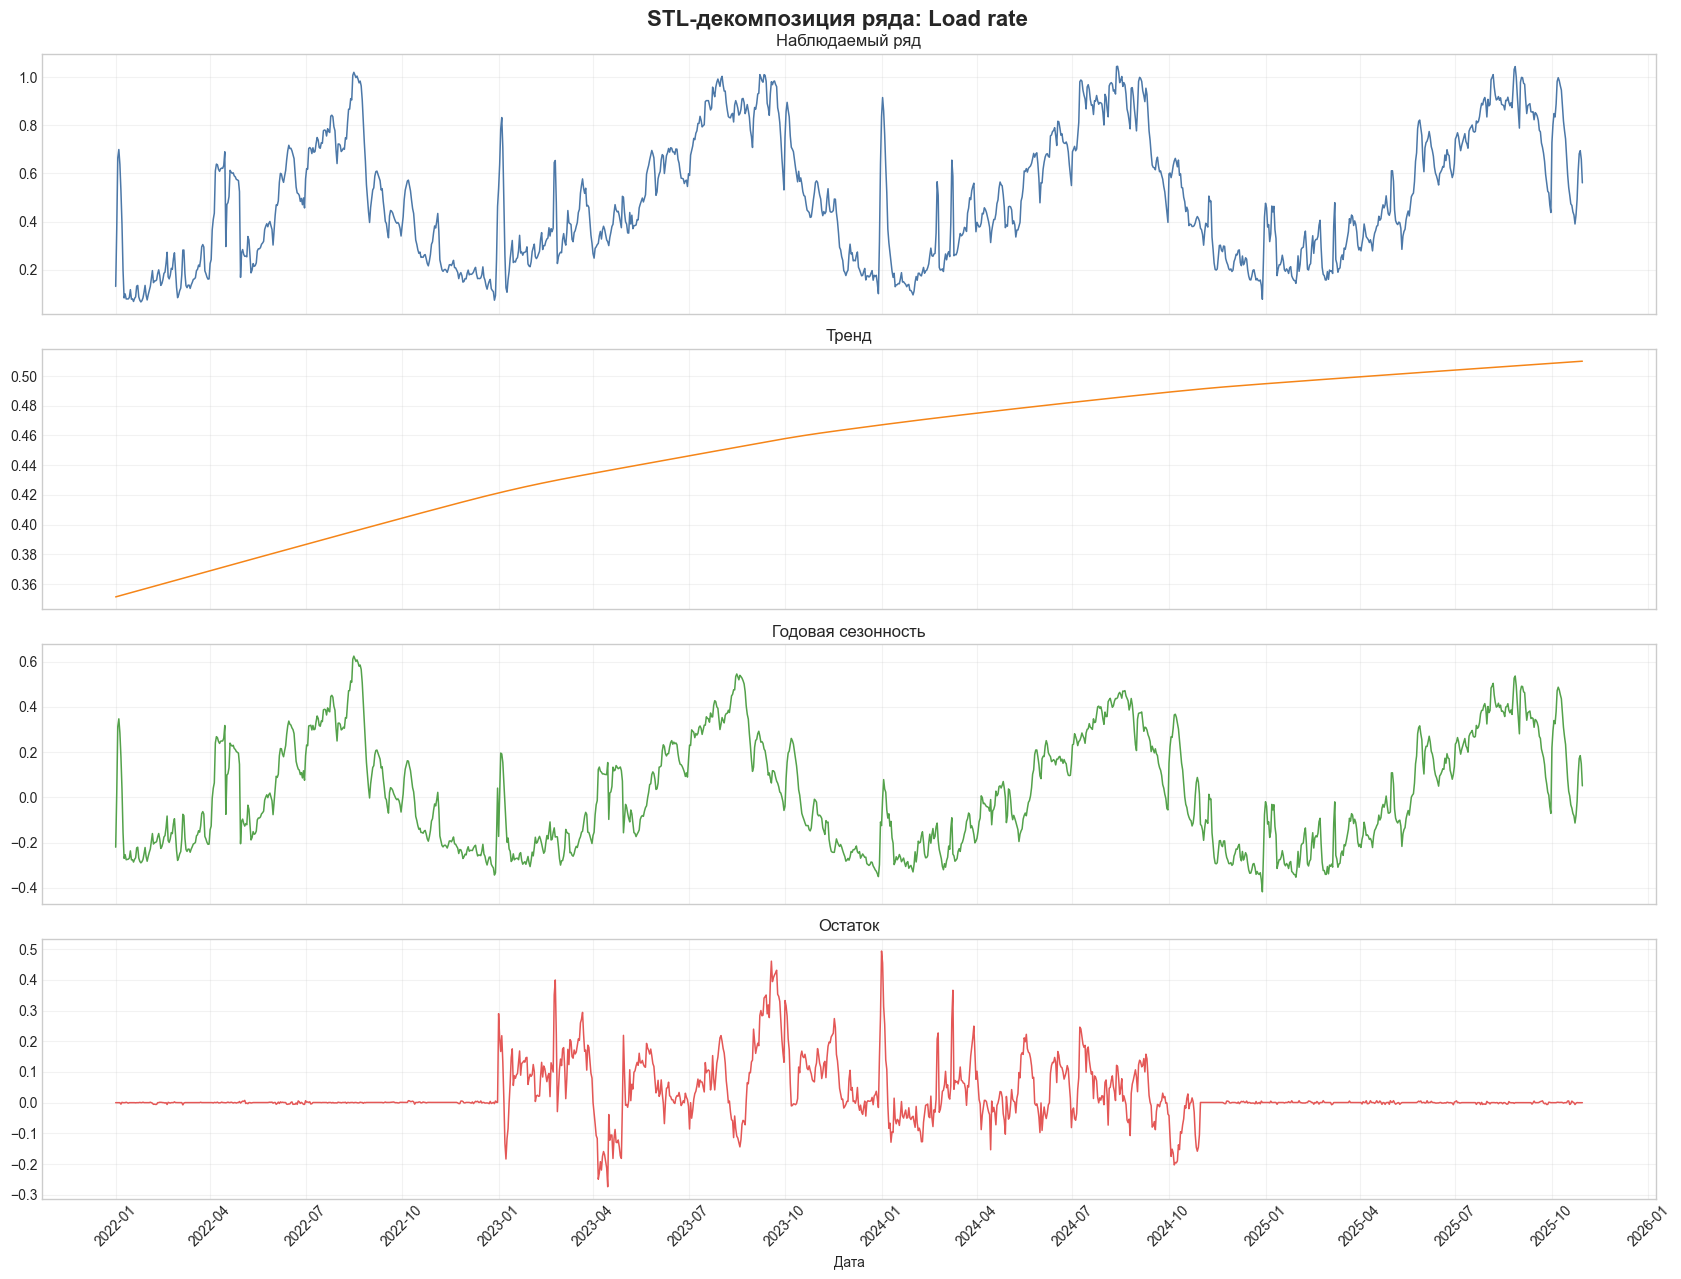

In [10]:
stl_series = df_occ.set_index('ds')[TARGET_FOR_EDA].asfreq('D').interpolate()
stl = STL(stl_series, period=365, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(17, 13), sharex=True)
fig.suptitle(f'STL-декомпозиция ряда: {TARGET_LABEL}', fontsize=16, fontweight='bold')

components = [
    ('Наблюдаемый ряд', stl_series, '#4C78A8'),
    ('Тренд', stl.trend, '#F58518'),
    ('Годовая сезонность', stl.seasonal, '#54A24B'),
    ('Остаток', stl.resid, '#E45756'),
]
for ax, (title, values, color) in zip(axes, components):
    ax.plot(values.index, values.values, color=color, linewidth=1.1)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
axes[-1].set_xlabel('Дата')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
save_current_fig('eda_stl_decomposition.png')
plt.show()


Сохранено: artifacts_forecasting\eda_seasonality_profiles.png


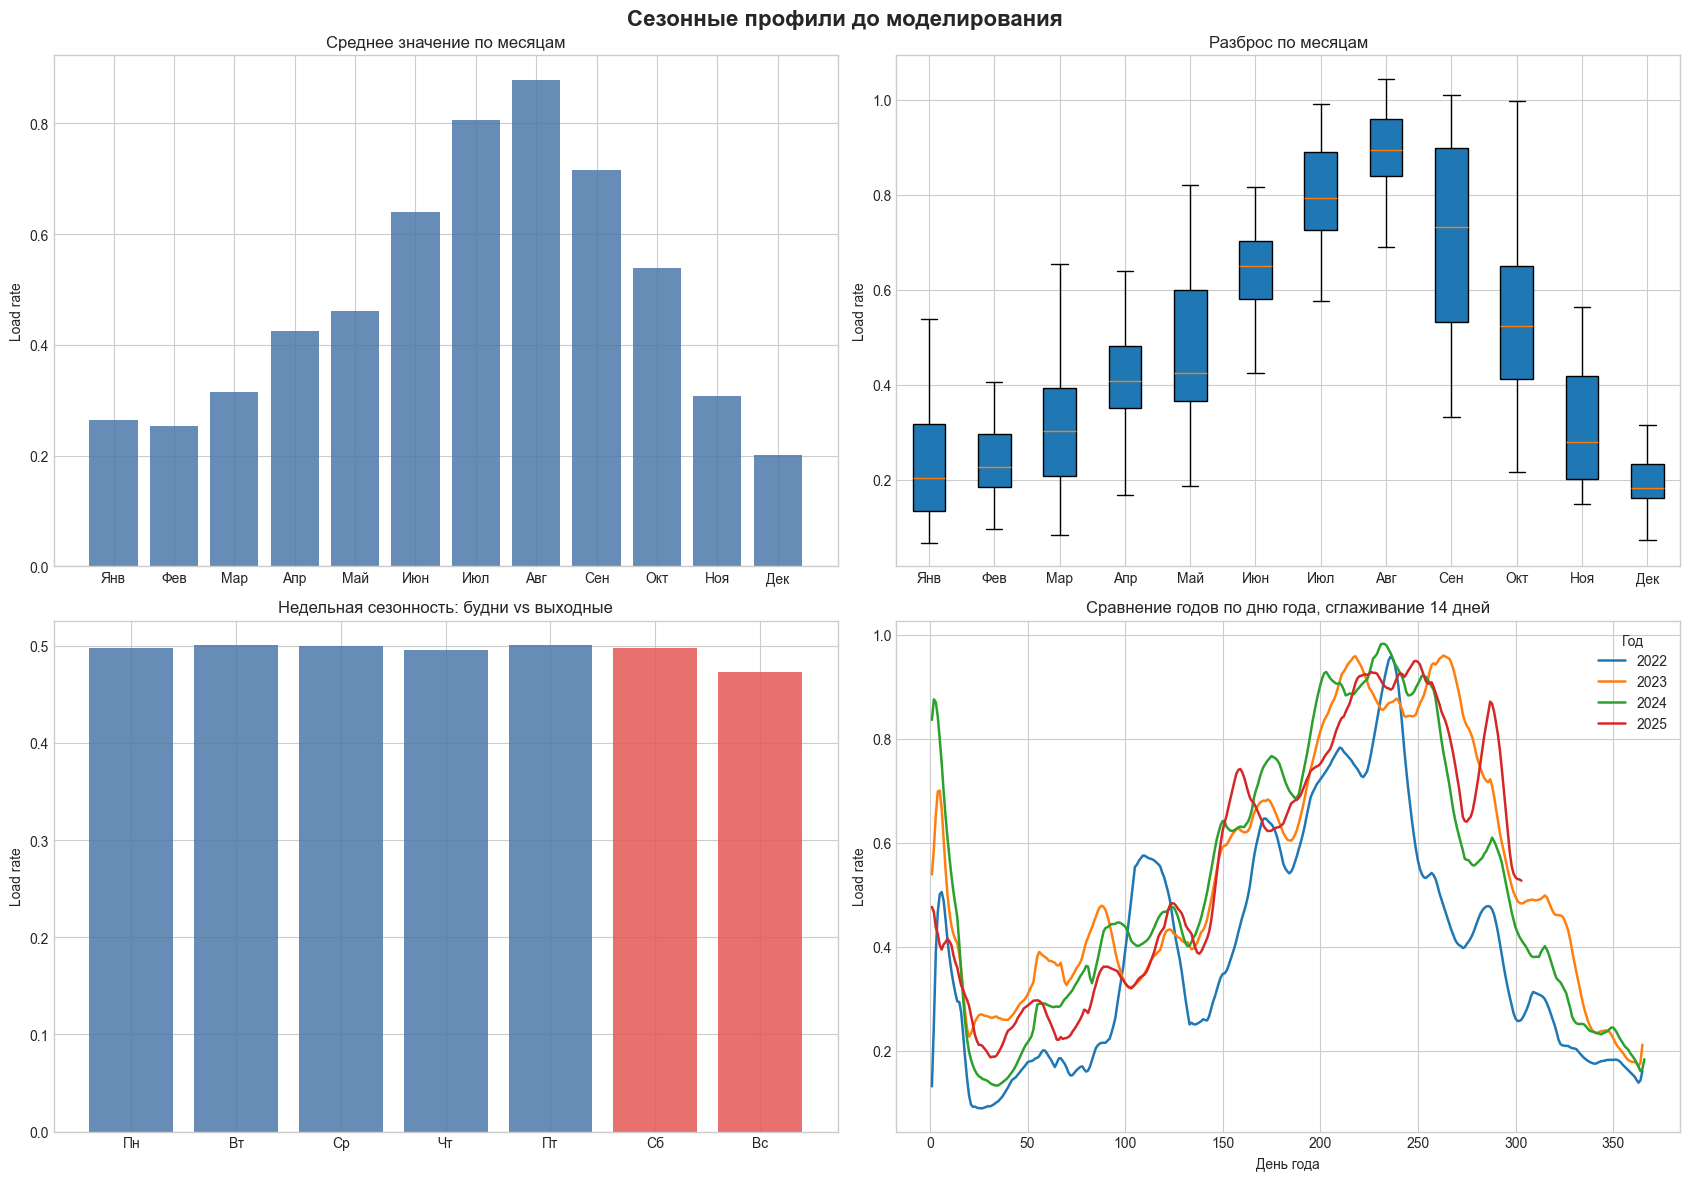

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(17, 12))
fig.suptitle('Сезонные профили до моделирования', fontsize=16, fontweight='bold')

monthly = df_occ.groupby('month')[TARGET_FOR_EDA].mean()
axes[0, 0].bar(monthly.index, monthly.values, color='#4C78A8', alpha=0.85)
axes[0, 0].set_title('Среднее значение по месяцам')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(MONTH_LABELS)
axes[0, 0].set_ylabel(TARGET_LABEL)

month_box = [df_occ.loc[df_occ['month'] == m, TARGET_FOR_EDA] for m in range(1, 13)]
axes[0, 1].boxplot(month_box, tick_labels=MONTH_LABELS, showfliers=False, patch_artist=True)
axes[0, 1].set_title('Разброс по месяцам')
axes[0, 1].set_ylabel(TARGET_LABEL)

weekday = df_occ.groupby('weekday')[TARGET_FOR_EDA].mean()
colors = ['#4C78A8' if day < 5 else '#E45756' for day in weekday.index]
axes[1, 0].bar(weekday.index, weekday.values, color=colors, alpha=0.85)
axes[1, 0].set_title('Недельная сезонность: будни vs выходные')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(WEEKDAY_LABELS)
axes[1, 0].set_ylabel(TARGET_LABEL)

yoy = df_occ.copy()
yoy['day_of_year'] = yoy['ds'].dt.dayofyear
for year, part in yoy.groupby('year'):
    smoothed = part.sort_values('day_of_year')[TARGET_FOR_EDA].rolling(14, min_periods=1).mean()
    axes[1, 1].plot(part['day_of_year'], smoothed, linewidth=1.8, label=str(year))
axes[1, 1].set_title('Сравнение годов по дню года, сглаживание 14 дней')
axes[1, 1].set_xlabel('День года')
axes[1, 1].set_ylabel(TARGET_LABEL)
axes[1, 1].legend(title='Год')

plt.tight_layout()
save_current_fig('eda_seasonality_profiles.png')
plt.show()


Сохранено: artifacts_forecasting\eda_calendar_heatmap.png


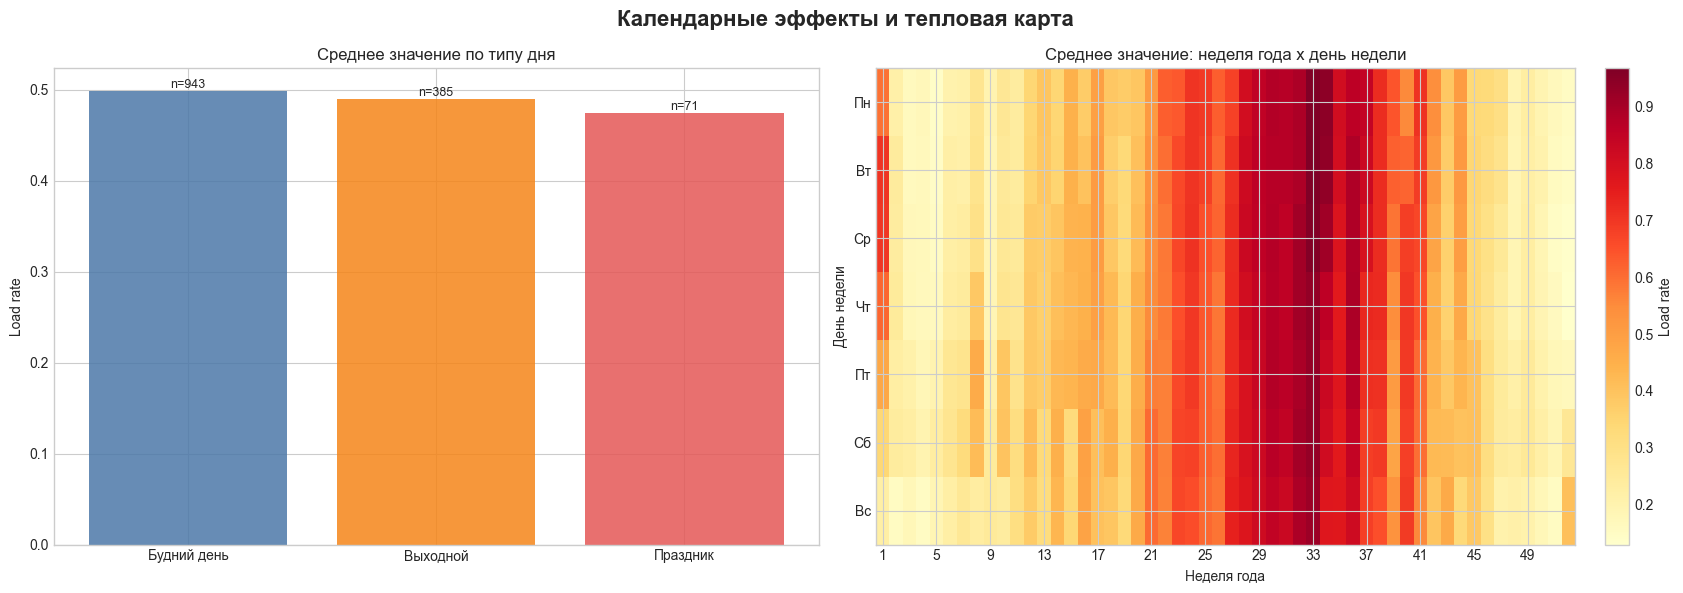

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Календарные эффекты и тепловая карта', fontsize=16, fontweight='bold')

calendar_summary = (
    df_occ.assign(day_type=np.select(
        [df_occ['is_holiday'].eq(1), df_occ['is_weekend'].eq(1)],
        ['Праздник', 'Выходной'],
        default='Будний день'
    ))
    .groupby('day_type')[TARGET_FOR_EDA]
    .agg(['mean', 'median', 'count'])
    .reindex(['Будний день', 'Выходной', 'Праздник'])
)
axes[0].bar(calendar_summary.index, calendar_summary['mean'], color=['#4C78A8', '#F58518', '#E45756'], alpha=0.85)
axes[0].set_title('Среднее значение по типу дня')
axes[0].set_ylabel(TARGET_LABEL)
for i, row in enumerate(calendar_summary.itertuples()):
    axes[0].text(i, row.mean, f'n={int(row.count)}', ha='center', va='bottom', fontsize=9)

heatmap_data = df_occ.pivot_table(index='weekday', columns='week', values=TARGET_FOR_EDA, aggfunc='mean')
im = axes[1].imshow(heatmap_data.values, aspect='auto', cmap='YlOrRd')
axes[1].set_title('Среднее значение: неделя года x день недели')
axes[1].set_xlabel('Неделя года')
axes[1].set_ylabel('День недели')
axes[1].set_yticks(range(7))
axes[1].set_yticklabels(WEEKDAY_LABELS)
axes[1].set_xticks(range(0, heatmap_data.shape[1], 4))
axes[1].set_xticklabels(heatmap_data.columns[::4])
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label=TARGET_LABEL)

plt.tight_layout()
save_current_fig('eda_calendar_heatmap.png')
plt.show()


Сохранено: artifacts_forecasting\eda_autocorrelation_residuals.png


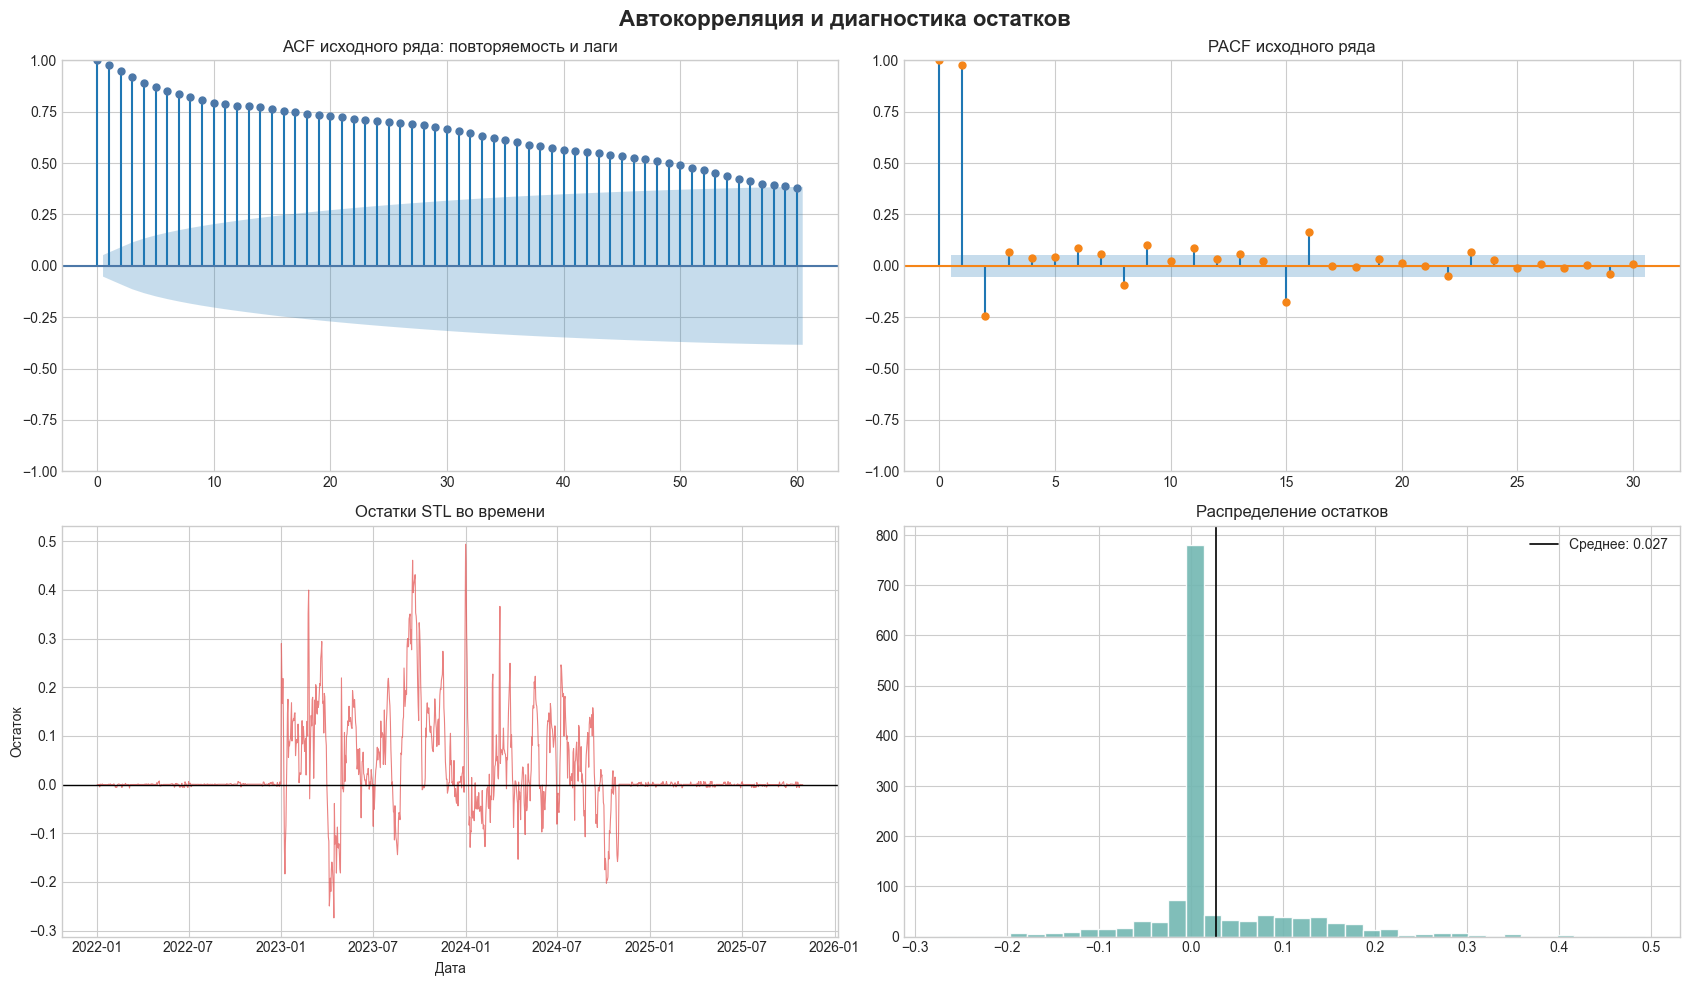

In [13]:
resid = pd.Series(stl.resid, index=stl_series.index).dropna()

fig, axes = plt.subplots(2, 2, figsize=(17, 10))
fig.suptitle('Автокорреляция и диагностика остатков', fontsize=16, fontweight='bold')

plot_acf(stl_series.dropna(), lags=60, ax=axes[0, 0], color='#4C78A8')
axes[0, 0].set_title('ACF исходного ряда: повторяемость и лаги')
plot_pacf(stl_series.dropna(), lags=30, ax=axes[0, 1], color='#F58518', method='ywm')
axes[0, 1].set_title('PACF исходного ряда')

axes[1, 0].plot(resid.index, resid.values, color='#E45756', linewidth=0.8, alpha=0.75)
axes[1, 0].axhline(0, color='black', linewidth=1)
axes[1, 0].set_title('Остатки STL во времени')
axes[1, 0].set_xlabel('Дата')
axes[1, 0].set_ylabel('Остаток')

axes[1, 1].hist(resid.values, bins=40, color='#72B7B2', alpha=0.9, edgecolor='white')
axes[1, 1].axvline(resid.mean(), color='black', linewidth=1.2, label=f'Среднее: {resid.mean():.3f}')
axes[1, 1].set_title('Распределение остатков')
axes[1, 1].legend()

plt.tight_layout()
save_current_fig('eda_autocorrelation_residuals.png')
plt.show()


## 9. Построение ряда по сегментам

In [14]:
# Загружаем результаты кластеризации — нам нужны только guest_id и cluster_v4
df_clusters = pd.read_parquet(
    CLUSTER_DIR / 'df_guests_with_clusters_v4.parquet',
    columns=['guest_id', 'cluster_v4']  # загружаем минимум нужных колонок
)

print(f'Загружено гостей с кластерами: {len(df_clusters):,}')
print(f'Распределение по кластерам:')
print(df_clusters['cluster_v4'].value_counts().sort_index())

Загружено гостей с кластерами: 248,547
Распределение по кластерам:
cluster_v4
0    55455
1    42148
2    47332
3    39520
4    47555
5    16537
Name: count, dtype: int64


In [15]:
# Присоединяем cluster_v4 к отфильтрованным данным бронирований
# LEFT JOIN: оставляем все бронирования, даже если гость не попал в кластеризацию
df_with_seg = df[['grp_norm', 'guest_id', 'check_in_dt', 'check_out_dt']].merge(
    df_clusters,
    on='guest_id',
    how='left'   # left join — не теряем бронирования без кластера
)

# Смотрим покрытие: сколько бронирований получили cluster_v4
covered = df_with_seg['cluster_v4'].notna().mean() * 100
print(f'Бронирований с известным сегментом: {covered:.1f}%')

# Оставляем только строки с известным сегментом для сегментного ряда
df_seg = df_with_seg.dropna(subset=['cluster_v4']).copy()
df_seg['cluster_v4'] = df_seg['cluster_v4'].astype(int)

print(f'Строк для сегментного ряда: {len(df_seg):,}')

Бронирований с известным сегментом: 84.2%
Строк для сегментного ряда: 272,828


In [16]:
df_seg_bookings = (
    df_seg.groupby(['grp_norm', 'cluster_v4'], as_index=False)
    .agg(
        check_in_dt  = ('check_in_dt',  'min'),
        check_out_dt = ('check_out_dt', 'max'),
    )
)

df_seg_bookings['check_in_dt']  = df_seg_bookings['check_in_dt'].dt.normalize()
df_seg_bookings['check_out_dt'] = df_seg_bookings['check_out_dt'].dt.normalize()

df_seg_bookings['date'] = df_seg_bookings.apply(
    lambda row: pd.date_range(
        start=row['check_in_dt'],
        end=row['check_out_dt'],
        inclusive='left'
    ),
    axis=1
)

df_seg_exploded = (
    df_seg_bookings
    .explode('date')[['cluster_v4', 'grp_norm', 'date']]
    .reset_index(drop=True)
)

df_seg_exploded = df_seg_exploded[
    (df_seg_exploded['date'] >= DATA_START) &
    (df_seg_exploded['date'] <= HISTORY_END)
]

df_daily_seg = (
    df_seg_exploded
    .groupby(['date', 'cluster_v4'])['grp_norm']
    .nunique()
    .reset_index()
    .rename(columns={'grp_norm': 'y', 'date': 'ds'})
)
df_daily_seg['ds'] = pd.to_datetime(df_daily_seg['ds'])
df_daily_seg['cluster_v4'] = df_daily_seg['cluster_v4'].astype(int)

print(f'Строк в сегментном ряду: {len(df_daily_seg):,}')
print('\nСредняя ежедневная загрузка по сегментам:')
print(df_daily_seg.groupby('cluster_v4')['y'].mean().round(1))
df_daily_seg.head(10)

Строк в сегментном ряду: 8,379

Средняя ежедневная загрузка по сегментам:
cluster_v4
0    105.1
1     44.3
2    150.3
3     39.6
4     45.3
5     63.3
Name: y, dtype: float64


,ds,cluster_v4,y
0,2022-01-01,0,3
1,2022-01-01,1,103
2,2022-01-01,2,10
3,2022-01-01,3,22
4,2022-01-01,4,5
5,2022-01-02,0,72
6,2022-01-02,1,101
7,2022-01-02,2,42
8,2022-01-02,3,62
9,2022-01-02,4,159


## 10. Визуализация загрузки по сегментам

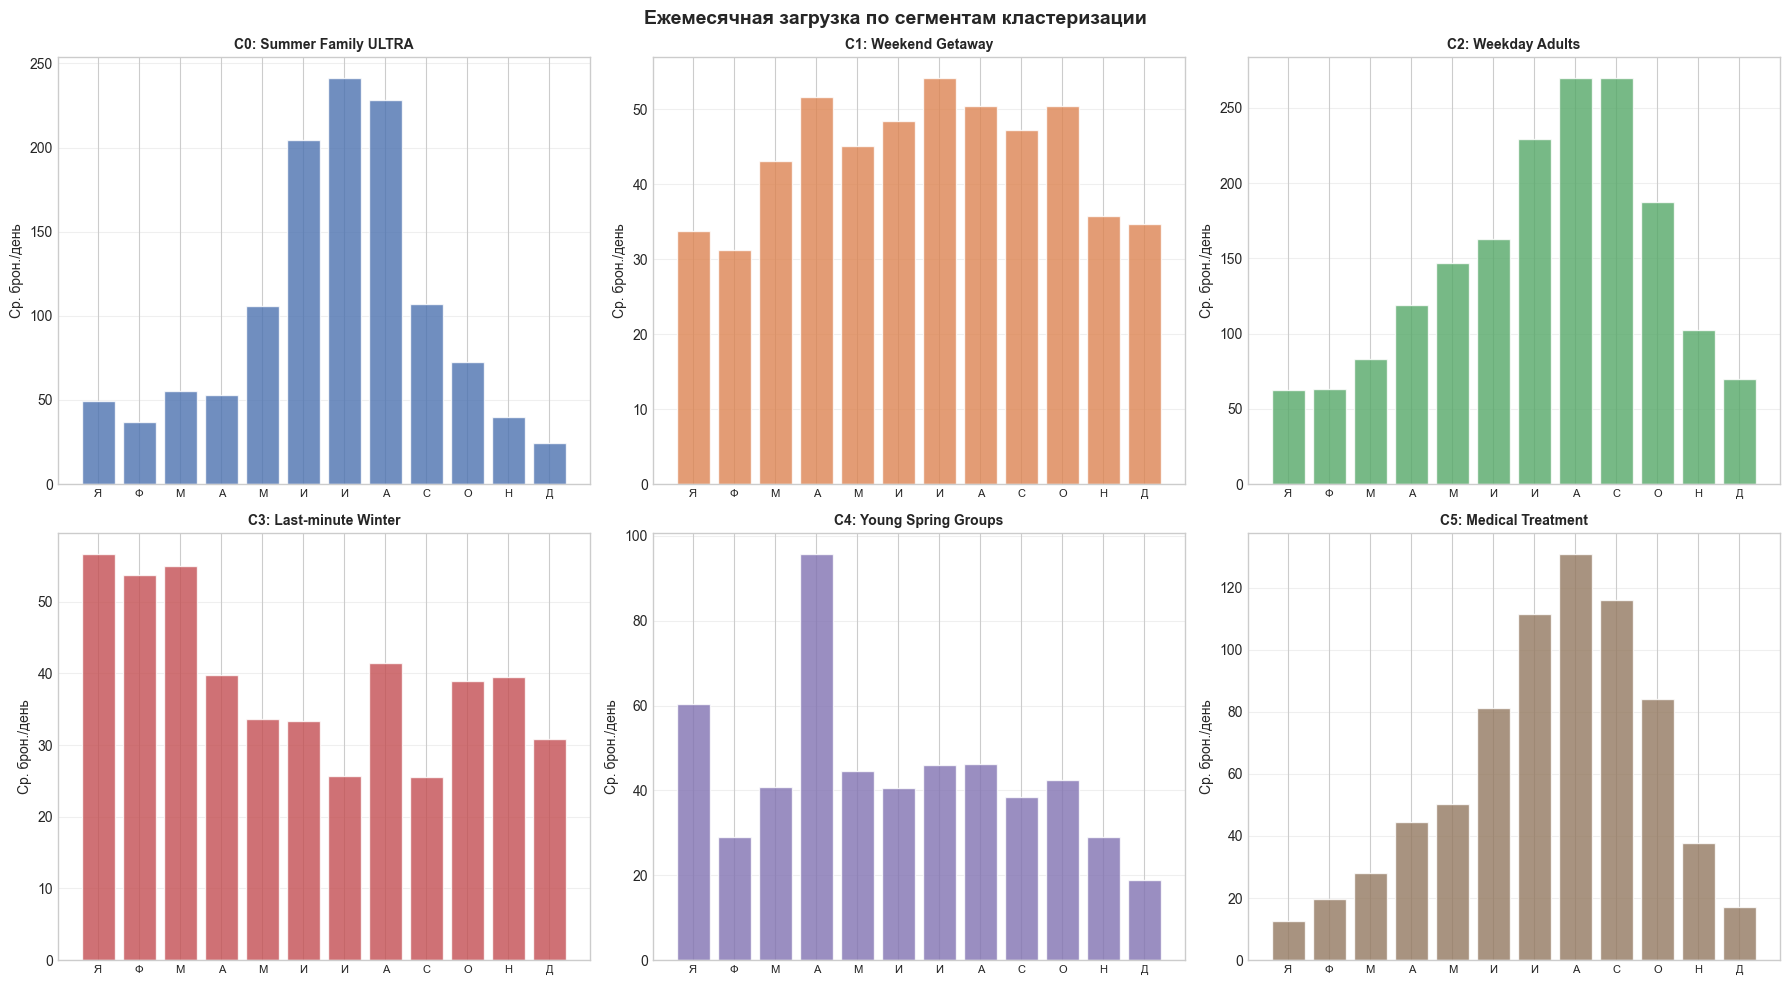

График сохранён в artifacts_forecasting/segment_monthly_load.png


In [17]:
# Названия сегментов из кластеризации v4
SEGMENT_NAMES = {
    0: 'C0: Summer Family ULTRA',
    1: 'C1: Weekend Getaway',
    2: 'C2: Weekday Adults',
    3: 'C3: Last-minute Winter',
    4: 'C4: Young Spring Groups',
    5: 'C5: Medical Treatment'
}
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Ежемесячная загрузка по сегментам кластеризации', fontsize=14, fontweight='bold')

df_daily_seg['month'] = df_daily_seg['ds'].dt.month

for idx, (cluster_id, ax) in enumerate(zip(range(6), axes.flatten())):
    seg_data = df_daily_seg[df_daily_seg['cluster_v4'] == cluster_id]
    monthly = seg_data.groupby('month')['y'].mean()

    ax.bar(monthly.index, monthly.values, color=COLORS[idx], alpha=0.8, edgecolor='white')
    ax.set_title(SEGMENT_NAMES[cluster_id], fontsize=10, fontweight='bold')
    ax.set_ylabel('Ср. брон./день')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Я','Ф','М','А','М','И','И','А','С','О','Н','Д'], fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUT_DIR / 'segment_monthly_load.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён в artifacts_forecasting/segment_monthly_load.png')

## 11. Сохранение артефактов

In [18]:
# Сохраняем общий дневной ряд
df_occ.to_parquet(OUT_DIR / 'df_daily.parquet', index=False)
print(f'Сохранено: df_daily.parquet — {len(df_occ):,} строк')
print(f'  Колонки: {list(df_occ.columns)}')

# Сохраняем сегментный дневной ряд
df_daily_seg.to_parquet(OUT_DIR / 'df_daily_segment.parquet', index=False)
print(f'\nСохранено: df_daily_segment.parquet — {len(df_daily_seg):,} строк')
print(f'  Колонки: {list(df_daily_seg.columns)}')

Сохранено: df_daily.parquet — 1,399 строк
  Колонки: ['ds', 'y', 'month', 'year', 'weekday', 'day_of_week', 'week', 'is_weekend', 'season', 'is_holiday', 'is_day_off', 'capacity_est', 'load_rate']

Сохранено: df_daily_segment.parquet — 8,379 строк
  Колонки: ['ds', 'cluster_v4', 'y', 'month']


## 12. Итоговая проверка качества ряда

In [19]:
print('=' * 55)
print('ИТОГОВАЯ ПРОВЕРКА КАЧЕСТВА ВРЕМЕННОГО РЯДА')
print('=' * 55)

# Проверка 1: нет пропусков в датах
date_gaps = df_occ['ds'].diff().dt.days.dropna()
has_gaps = (date_gaps != 1).any()
print(f'[{"FAIL" if has_gaps else "OK"}] Пропуски в датах: {has_gaps}')

# Проверка 2: диапазон дат разумный
print(f'[OK] Диапазон: {df_occ["ds"].min().date()} — {df_occ["ds"].max().date()}')
print(f'[OK] Длина ряда: {len(df_occ):,} дней')

# Проверка 3: нет экстремальных выбросов
y_max = df_occ['y'].max()
y_mean = df_occ['y'].mean()
print(f'[OK] Макс. загрузка: {y_max} (в {y_max/y_mean:.1f}x от среднего {y_mean:.0f})')

# Проверка 4: доля нулевых дней
zero_pct = (df_occ['y'] == 0).mean() * 100
print(f'[{"WARN" if zero_pct > 5 else "OK"}] Дней с нулевой загрузкой: {zero_pct:.1f}%')

# Проверка 5: все 6 сегментов присутствуют
n_segs = df_daily_seg['cluster_v4'].nunique()
print(f'[{"OK" if n_segs == 6 else "FAIL"}] Сегментов в ряду: {n_segs}/6')

print('=' * 55)
print('Готово! Следующий шаг → 02_prophet_baseline.ipynb')

ИТОГОВАЯ ПРОВЕРКА КАЧЕСТВА ВРЕМЕННОГО РЯДА
[OK] Пропуски в датах: False
[OK] Диапазон: 2022-01-01 — 2025-10-30
[OK] Длина ряда: 1,399 дней
[OK] Макс. загрузка: 992 (в 2.3x от среднего 438)
[OK] Дней с нулевой загрузкой: 0.0%
[OK] Сегментов в ряду: 6/6
Готово! Следующий шаг → 02_prophet_baseline.ipynb


In [20]:
from pathlib import Path
import pandas as pd

OUT_DIR = Path('artifacts_forecasting')
CAPACITY_QUANTILE = 0.99

def month_to_season(month: int) -> str:
    if month in (12, 1, 2):
        return 'winter'
    if month in (3, 4, 5):
        return 'spring'
    if month in (6, 7, 8):
        return 'summer'
    return 'autumn'

df_occ['ds'] = pd.to_datetime(df_occ['ds'])
df_occ['year'] = df_occ['ds'].dt.year
if 'season' not in df_occ.columns:
    df_occ['season'] = df_occ['ds'].dt.month.map(month_to_season)

capacity_by_year = (
    df_occ.groupby('year')['y']
    .quantile(CAPACITY_QUANTILE)
    .round()
    .astype(int)
    .to_dict()
)

df_occ['capacity_est'] = df_occ['year'].map(capacity_by_year).astype(float)
df_occ['load_rate'] = (df_occ['y'] / df_occ['capacity_est']).clip(lower=0, upper=1.2)

capacity_check = (
    df_occ.groupby('year')
    .agg(
        max_y=('y', 'max'),
        p99_y=('y', lambda s: s.quantile(CAPACITY_QUANTILE)),
        p98_y=('y', lambda s: s.quantile(0.98)),
        mean_y=('y', 'mean'),
        capacity_est=('capacity_est', 'first'),
        days=('y', 'size'),
    )
    .round(1)
    .reset_index()
)

OUT_DIR.mkdir(exist_ok=True)
df_occ.to_parquet(OUT_DIR / 'df_daily.parquet', index=False)
capacity_check.to_csv(OUT_DIR / 'capacity_by_year.csv', index=False, encoding='utf-8-sig')

print('???????? ???? ?????? ??? p99 ???????? ???????????? ?????? ??????? ????.')
print(f'?????????: {OUT_DIR / "df_daily.parquet"}')
print(f'?????????: {OUT_DIR / "capacity_by_year.csv"}')
display(capacity_check)


???????? ???? ?????? ??? p99 ???????? ???????????? ?????? ??????? ????.
?????????: artifacts_forecasting\df_daily.parquet
?????????: artifacts_forecasting\capacity_by_year.csv


,year,max_y,p99_y,p98_y,mean_y,capacity_est,days
0,2022,980,961.2,934.6,376.4,961.0,365
1,2023,992,982.4,966.7,522.0,982.0,365
2,2024,861,824.0,812.8,419.1,824.0,366
3,2025,813,779.0,777.0,435.8,779.0,303
